In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_theme(style='whitegrid')

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("AIML Dataset.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [7]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [4]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [15]:
fraud_count = df['isFraud'].value_counts()[1]
total = df['isFraud'].value_counts()[0] + df['isFraud'].value_counts()[1]

print(fraud_count, total)
print(f"{round(fraud_count / total * 100, 2)}% fraud rate")

8213 6362620
0.13% fraud rate


In [6]:
df['isFlaggedFraud'].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

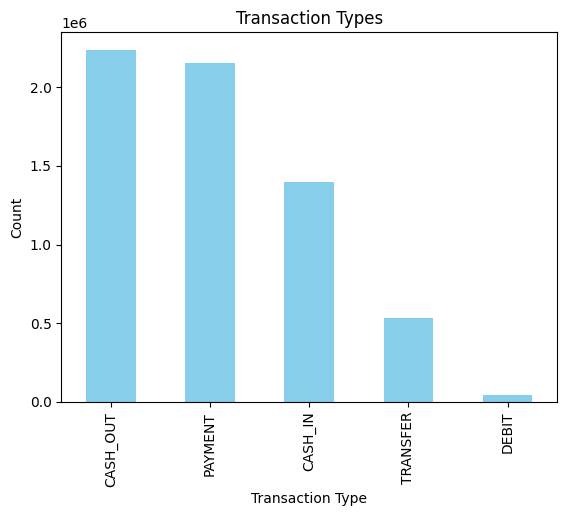

In [16]:
df['type'].value_counts().plot(kind='bar', title='Transaction Types', color='skyblue')
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

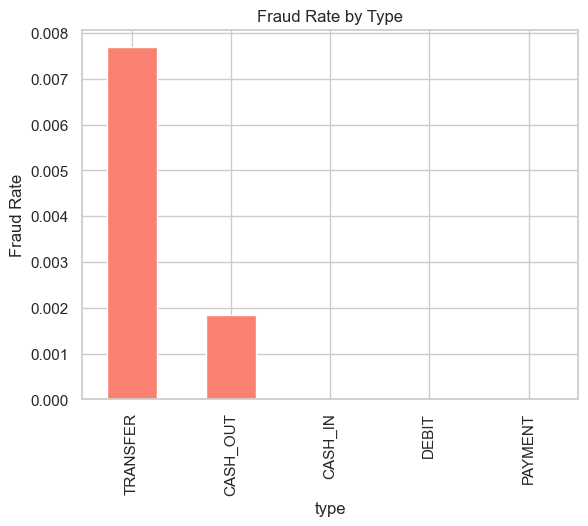

In [18]:
fraud_by_type = df.groupby('type')['isFraud'].mean().sort_values(ascending=False)
fraud_by_type.plot(kind='bar', title="Fraud Rate by Type", color='salmon')
plt.ylabel("Fraud Rate")
plt.show()

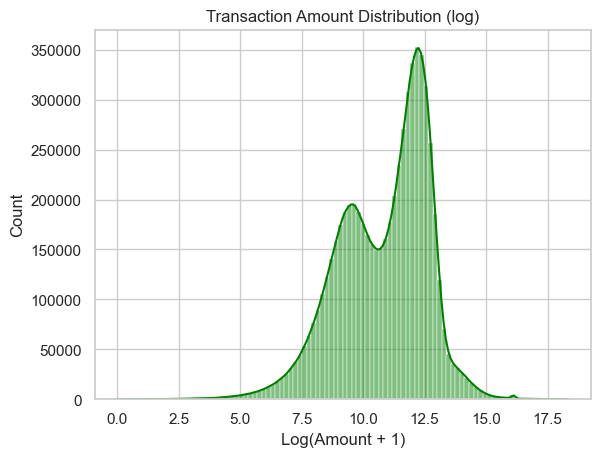

In [19]:
sns.histplot(np.log1p(df['amount']), bins=100, kde=True, color='green')
plt.title("Transaction Amount Distribution (log)")
plt.xlabel("Log(Amount + 1)")
plt.show()

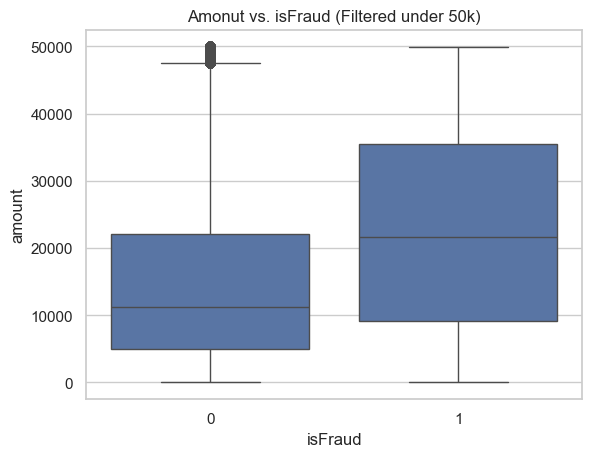

In [20]:
sns.boxplot(data=df[df['amount'] < 50000], x='isFraud', y='amount')
plt.title("Amonut vs. isFraud (Filtered under 50k)")
plt.show()

In [21]:
df['balanceDiffOrig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balanceDiffDest'] = df['newbalanceDest'] - df['oldbalanceDest']


In [26]:
(df['balanceDiffOrig'] < 0).sum()

np.int64(1399253)

In [25]:
(df['balanceDiffDest'] < 0).sum()

np.int64(1238864)

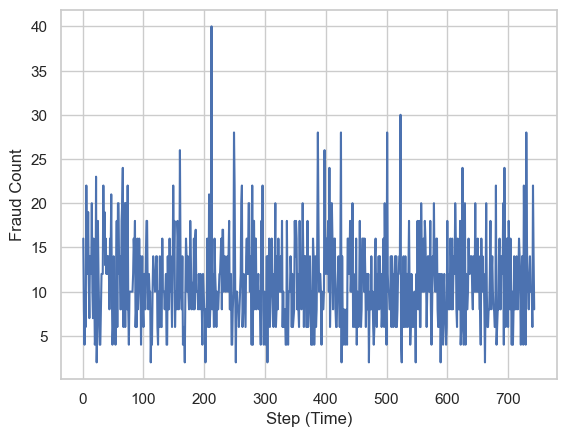

In [ ]:
frauds_per_step = df[df['isFraud'] == 1]['step'].value_counts().sort_index()
plt.plot(frauds_per_step.index, frauds_per_step.values, label='Frauds Per Step')
plt.xlabel("Step (Time)")
plt.ylabel("Fraud Count")
plt.grid(True)
plt.show()
# (Fraud is not time dependent)

In [ ]:
df.drop(columns='step', inplace=True)